# Access 4DMED-2D PFT and Kd
    * Original Data Source: https://zenodo.org/records/17077475
    * Reference:  https://zenodo.org/records/17077475
    * OSC entry: https://opensciencedata.esa.int/products/4dmed-2d-pft-kd/collection
    * License: CC-BY-4.0

In [1]:
import xarray as xr

zarr_href = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/4dmed-2d-pft.zarr/'

In [2]:
ds = xr.open_zarr(zarr_href)
ds

<xarray.Dataset> Size: 278MB
Dimensions:  (time: 36, lat: 278, lon: 694)
Coordinates:
  * time     (time) datetime64[ns] 288B 2019-01-01 2019-02-01 ... 2021-12-01
  * lat      (lat) float64 2kB 30.04 30.11 30.18 30.25 ... 49.86 49.93 50.0
  * lon      (lon) float64 6kB -9.964 -9.892 -9.82 -9.748 ... 39.84 39.91 39.98
Data variables:
    DIATO    (time, lat, lon) float64 56MB dask.array<chunksize=(36, 278, 694), meta=np.ndarray>
    DINO     (time, lat, lon) float64 56MB dask.array<chunksize=(36, 278, 694), meta=np.ndarray>
    GREEN    (time, lat, lon) float64 56MB dask.array<chunksize=(36, 278, 694), meta=np.ndarray>
    HAPTO    (time, lat, lon) float64 56MB dask.array<chunksize=(36, 278, 694), meta=np.ndarray>
    PROKA    (time, lat, lon) float64 56MB dask.array<chunksize=(36, 278, 694), meta=np.ndarray>
Attributes:
    title:        Gridded phytoplankton functional types (PFTs) at 8.0 km res...
    institution:  Alfred Wegener Institute
    source:       Extracted from Copernicus Marine Service OCEANCOLOUR_GLO_BG...
    history:      Created on 02-Jun-2025 14:44:02

# Plot the phytoplankton functional type contributing the most chlorophyll at each grid cell during the summer months


In [13]:
import numpy as np
import xarray as xr

pft_names = ["DIATO", "DINO", "GREEN", "HAPTO", "PROKA"]

pft = ds[pft_names].to_array(dim="pft")
summer = pft.sel(
    time=pft.time.dt.month.isin([6, 7, 8])
).mean("time")


total_chlorophyll is the combined chlorophyll concentration of the five groups. dominant_pft stores the index of the group with the highest concentration at each grid cell.

In [14]:
total_chlorophyll = summer.sum("pft", min_count=1)

dominant_pft = (
    summer.fillna(-np.inf)
    .argmax("pft")
    .where(total_chlorophyll.notnull())
)

total_chlorophyll = total_chlorophyll.compute()
dominant_pft = dominant_pft.compute()

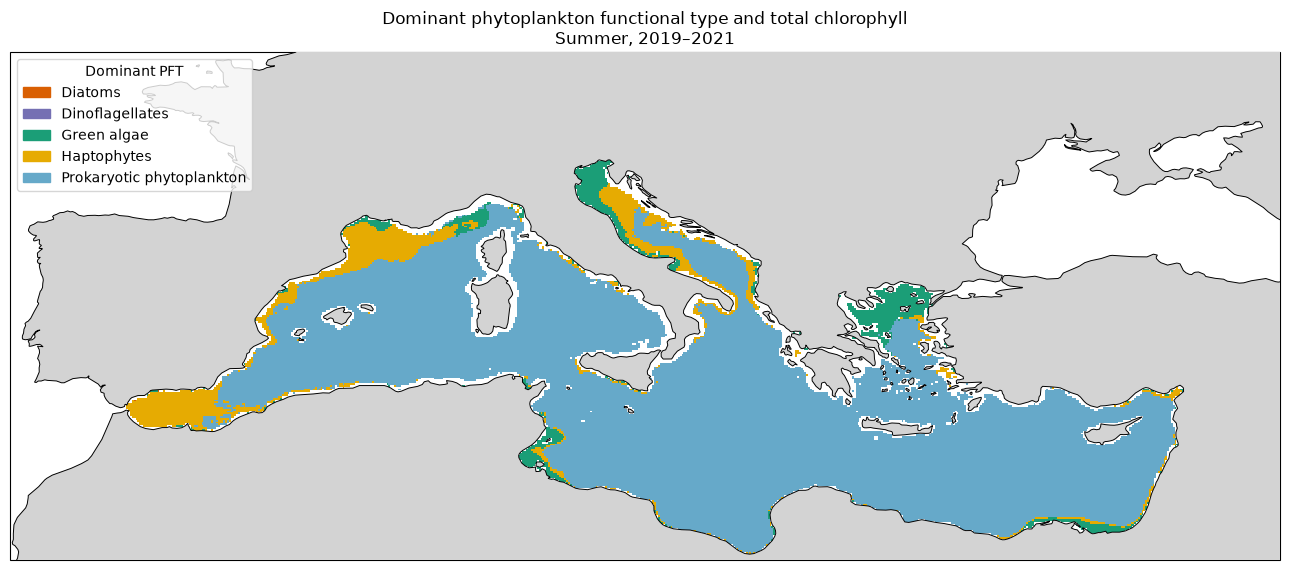

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

pft_colours = [
    "#d95f02",  # Diatoms
    "#7570b3",  # Dinoflagellates
    "#1b9e77",  # Green algae
    "#e6ab02",  # Haptophytes
    "#66a9c9",  # Prokaryotic phytoplankton
]

pft_labels = [
    "Diatoms",
    "Dinoflagellates",
    "Green algae",
    "Haptophytes",
    "Prokaryotic phytoplankton",
]

cmap = ListedColormap(pft_colours)
norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), cmap.N)

projection = ccrs.PlateCarree()

fig = plt.figure(figsize=(13, 7))
ax = plt.axes(projection=projection)

ax.set_extent(
    [
        float(ds.lon.min()),
        float(ds.lon.max()),
        float(ds.lat.min()),
        float(ds.lat.max()),
    ],
    crs=projection,
)

ax.pcolormesh(
    ds.lon,
    ds.lat,
    dominant_pft,
    cmap=cmap,
    norm=norm,
    shading="auto",
    transform=projection,
)


ax.add_feature(cfeature.LAND, facecolor="lightgrey", zorder=3)
ax.coastlines(resolution="50m", linewidth=0.7, zorder=4)

legend_handles = [
    mpatches.Patch(color=colour, label=label)
    for colour, label in zip(pft_colours, pft_labels)
]

ax.legend(
    handles=legend_handles,
    title="Dominant PFT",
    loc="upper left",
    frameon=True,
)

ax.set_title(
    "Dominant phytoplankton functional type and total chlorophyll\n"
    "Summer, 2019–2021"
)

plt.tight_layout()
plt.show()